# **Data Exploration And Visualiation**

**Loading Dataset**

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# from google.colab import files
# uploaded = files.upload()

import zipfile, io
# Assuming the .ip file is a zip file, try to unzip it
try:
    with zipfile.ZipFile('Flower Classification.zip', 'r') as zip_ref:
        zip_ref.extractall('Data')
    print("File unzipped successfully.")
except zipfile.BadZipFile:
    print("Error: The file is not a valid zip file. Please check the file or upload a valid zip archive.")
except FileNotFoundError:
    print("Error: The file 'Flower Classification.ip' was not found. Please make sure the file is uploaded.")


# Unip file


# Load train and validation datasets
train_dir = "Data/Data/train"
val_dir = "Data/Data/val"

img_size = (256, 256)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# (Optional but recommended) performance tweaks for input pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

File unzipped successfully.
Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.


**Explore Dateset Basics**

In [ ]:
img_size = (256, 256)
batch_size = 8

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds_raw.class_names

# (Optional but recommended) performance tweaks for input pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.prefetch(AUTOTUNE)


# Print the class names
print("Flower Classes:", class_names)

# Count number of images
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in val_ds.unbatch())
print(f"Training images: {train_count}")
print(f"Validation images: {val_count}")

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Flower Classes: ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']
Training images: 13642
Validation images: 98


**Visualise Sample Images per class**

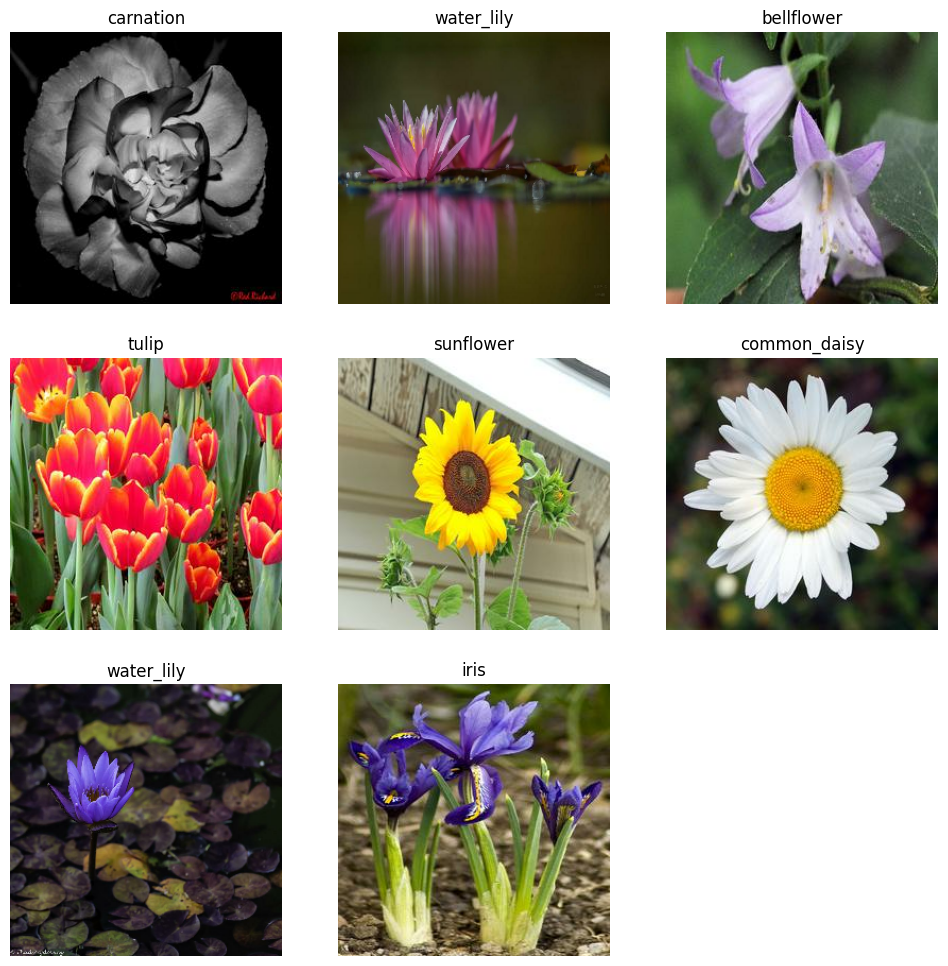

In [ ]:
import matplotlib.pyplot as plt

def visualize_images(dataset, class_names):
    plt.figure(figsize=(12, 12))
    for images, labels in dataset.take(1):  # Take one batch
        for i in range(8):  # Change range to 8 to match batch size
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.show()

visualize_images(train_ds, class_names)

**Anticipating classification challenges**

Some flowers have similar colors (e.g., roses and tulips), making it difficult for the model to differentiate them. Lighting conditions and background clutter can also confuse the model. Intra-class variation (the same flower looking very different depending on angle or bloom stage) adds another challenge. Therefore, data augmentation will likely help in improving generalization.

# **Model Architecture Design**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 14
img_size = (256, 256)
batch_size = 8

# Load train and validation datasets
train_dir = "Data/Data/train"
val_dir = "Data/Data/val"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# (Optional but recommended) performance tweaks for input pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.prefetch(AUTOTUNE)


# --- Baseline CNN ---
def build_baseline_cnn(input_shape=(256, 256, 3), num_classes=14, dropout_rate=0.3):
    inputs = keras.Input(shape=input_shape)

    # Block 1: Learn simple edges/colors/textures
    x = layers.Rescaling(1./255)(inputs)                  # normalize pixels to [0,1]
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)                     # downsample (256→128)

    # Block 2: Learn more complex textures/parts
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)                     # 128→64

    # Block 3: Learn higher-level shapes (petals/centers)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)                     # 64→32

    # Flatten + classifier head
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_rate)(x)                   # reduce overfitting
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="flowers_baseline_cnn")
    return model

baseline_model = build_baseline_cnn(input_shape=img_size + (3,), num_classes=num_classes)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",               # labels are integers 0..13
    metrics=["accuracy"]
)

baseline_model.summary()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.


Model: "flowers_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,651,534 (128.37 MB)

 Trainable params: 33,651,534 (128.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - accuracy: 0.3334 - loss: 1.9455 - val_accuracy: 0.5306 - val_loss: 1.2977
Epoch 2/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.5940 - loss: 1.1927 - val_accuracy: 0.6327 - val_loss: 1.0987
Epoch 3/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.7162 - loss: 0.8521 - val_accuracy: 0.6735 - val_loss: 0.9724
Epoch 4/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8211 - loss: 0.5263 - val_accuracy: 0.7347 - val_loss: 1.0834
Epoch 5/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8814 - loss: 0.3548 - val_accuracy: 0.6429 - val_loss: 1.0871
Epoch 6/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9195 - loss: 0.2441 - val_accuracy: 0.6531 - val_loss: 1.2697
Epoch 7/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9423 - loss: 0.1929 - val_accuracy: 0.7041 - val_loss: 1.7193
Epoch 8/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9456 -

**Batch Normalisation**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 14
img_size = (256, 256)
batch_size = 8

# Load train and validation datasets
train_dir = "Data/Data/train"
val_dir = "Data/Data/val"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# (Optional but recommended) performance tweaks for input pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.prefetch(AUTOTUNE)


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return layers.MaxPooling2D(2)(x)

def build_bn_cnn(input_shape=(256,256,3), num_classes=14, dropout_rate=0.4):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)

    x = conv_block(x, 32)    # 256→128
    x = conv_block(x, 64)    # 128→64
    x = conv_block(x, 128)   # 64→32

    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="flowers_bn_cnn")
    return model

bn_model = build_bn_cnn(input_shape=img_size + (3,), num_classes=num_classes)

bn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bn_model.summary()

history_bn = bn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.


Model: "flowers_bn_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 128)    │             

 Total params: 67,404,910 (257.13 MB)

 Trainable params: 67,404,014 (257.13 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 138s 65ms/step - accuracy: 0.0835 - loss: 12.2835 - val_accuracy: 0.0714 - val_loss: 2.6087
Epoch 2/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - accuracy: 0.0696 - loss: 2.6373 - val_accuracy: 0.0714 - val_loss: 2.6425
Epoch 3/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - accuracy: 0.0741 - loss: 2.6406 - val_accuracy: 0.0714 - val_loss: 2.6432
Epoch 4/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 141s 58ms/step - accuracy: 0.0727 - loss: 2.6353 - val_accuracy: 0.0714 - val_loss: 2.6430
Epoch 5/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 103s 58ms/step - accuracy: 0.0750 - loss: 2.6372 - val_accuracy: 0.0714 - val_loss: 2.6430
Epoch 6/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - accuracy: 0.0777 - loss: 2.6357 - val_accuracy: 0.0714 - val_loss: 2.6431
Epoch 7/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 103s 58ms/step - accuracy: 0.0780 - loss: 2.6358 - val_accuracy: 0.0714 - val_loss: 2.6431
Epoch 8/12
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - accuracy: